In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

# decision tree for multioutput regression
from sklearn.datasets import make_regression
from sklearn.tree import DecisionTreeRegressor

# KNN for multioutput regression
from sklearn.datasets import make_regression
from sklearn.neighbors import KNeighborsRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
#from scipy.io import arff

import matplotlib.pyplot as plot
import pandas


In [ ]:
#data = arff.loadarff('yeast-train.arff')
#df = pd.DataFrame(data[0])

#df.head()

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Hasan sir/new_analysis/desharnais.csv')
df.head(5)

,id,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,1,1,4,85,12,5152,253,52,305,34,302,1
1,2,2,0,0,86,4,5635,197,124,321,33,315,1
2,3,3,4,4,85,1,805,40,60,100,18,83,1
3,4,4,0,0,86,5,3829,200,119,319,30,303,1
4,5,5,0,0,86,4,2149,140,94,234,24,208,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               81 non-null     int64
 1   Project          81 non-null     int64
 2   TeamExp          81 non-null     int64
 3   ManagerExp       81 non-null     int64
 4   YearEnd          81 non-null     int64
 5   Length           81 non-null     int64
 6   Effort           81 non-null     int64
 7   Transactions     81 non-null     int64
 8   Entities         81 non-null     int64
 9   PointsNonAdjust  81 non-null     int64
 10  Adjustment       81 non-null     int64
 11  PointsAjust      81 non-null     int64
 12  Language         81 non-null     int64
dtypes: int64(13)
memory usage: 8.4 KB


In [5]:
df.describe()

,id,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
count,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000,81.000000
mean,41.000000,41.000000,2.185185,2.530864,85.740741,11.666667,5046.308642,182.123457,122.333333,304.456790,27.629630,289.234568,1.555556
std,23.526581,23.526581,1.415195,1.643825,1.222475,7.424621,4418.767228,144.035098,84.882124,180.210159,10.591795,185.761088,0.707107
min,1.000000,1.000000,-1.000000,-1.000000,82.000000,1.000000,546.000000,9.000000,7.000000,73.000000,5.000000,62.000000,1.000000
25%,21.000000,21.000000,1.000000,1.000000,85.000000,6.000000,2352.000000,88.000000,57.000000,176.000000,20.000000,152.000000,1.000000
50%,41.000000,41.000000,2.000000,3.000000,86.000000,10.000000,3647.000000,140.000000,99.000000,266.000000,28.000000,255.000000,1.000000
75%,61.000000,61.000000,4.000000,4.000000,87.000000,14.000000,5922.000000,224.000000,169.000000,384.000000,35.000000,351.000000,2.000000
max,81.000000,81.000000,4.000000,7.000000,88.000000,39.000000,23940.000000,886.000000,387.000000,1127.000000,52.000000,1116.000000,3.000000


In [6]:
df

,id,Project,TeamExp,ManagerExp,YearEnd,Length,Effort,Transactions,Entities,PointsNonAdjust,Adjustment,PointsAjust,Language
0,1,1,1,4,85,12,5152,253,52,305,34,302,1
1,2,2,0,0,86,4,5635,197,124,321,33,315,1
2,3,3,4,4,85,1,805,40,60,100,18,83,1
3,4,4,0,0,86,5,3829,200,119,319,30,303,1
4,5,5,0,0,86,4,2149,140,94,234,24,208,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,77,77,4,4,85,12,1400,229,169,398,39,414,3
77,78,78,4,3,83,12,2800,227,73,300,34,297,1
78,79,79,4,4,82,24,9520,395,193,588,40,617,1
79,80,80,4,3,86,12,5880,469,176,645,43,697,3


<Axes: title={'center': 'Pearson Correlation of Features'}>

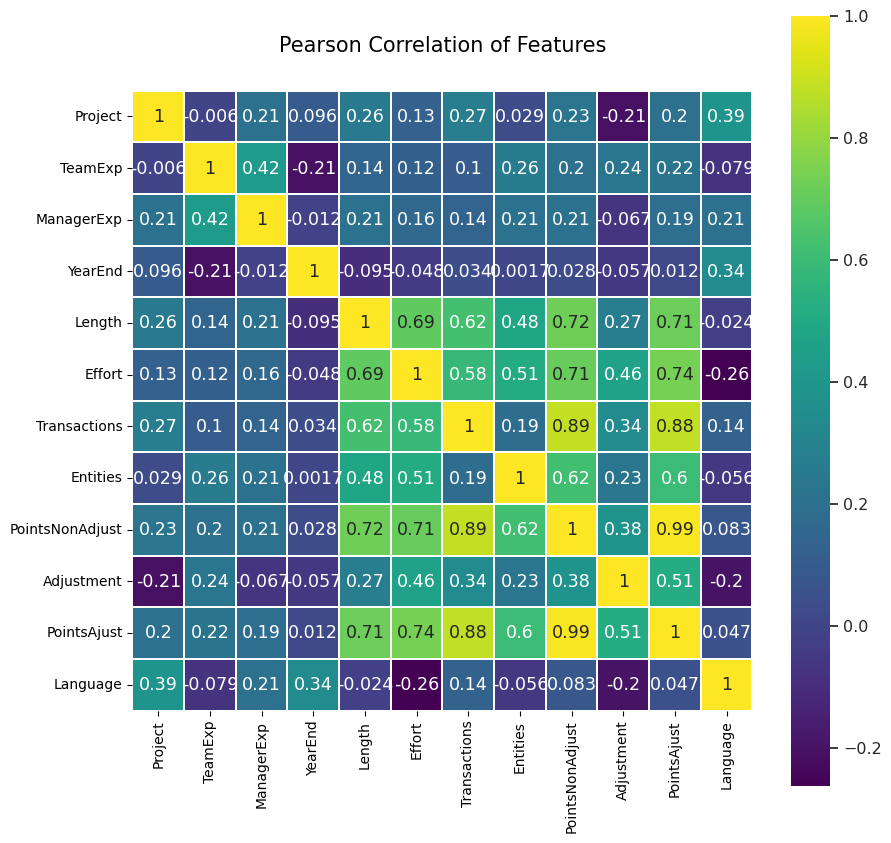

In [7]:
colormap = plt.cm.viridis
plt.figure(figsize=(10,10))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.set(font_scale=1.05)
sns.heatmap(df.drop(['id'], axis=1).astype(float).corr(),linewidths=0.1,vmax=1.0, square=True,cmap=colormap, linecolor='white', annot=True)

In [8]:
# map features to their absolute correlation values
corr = df.corr().abs()

# set equality (self correlation) as zero
corr[corr == 1] = 0

# of each feature, find the max correlation
# and sort the resulting array in ascending order
corr_cols = corr.max().sort_values(ascending=False)

# display the highly correlated fe
#corr_cols

# display the highly correlated features
display(corr_cols[corr_cols > 0.6])

PointsNonAdjust    0.985945
PointsAjust        0.985945
Transactions       0.886419
Effort             0.738271
Length             0.723849
Entities           0.618913
dtype: float64

In [9]:
features = [ 'TeamExp', 'ManagerExp', 'YearEnd', 'Length', 'Transactions', 'Entities',
        'PointsNonAdjust', 'Adjustment', 'PointsAjust']

max_corr_features = ['Length', 'Transactions', 'Entities','PointsNonAdjust','PointsAjust']

X = df[max_corr_features]
y = df['Effort']

In [10]:
# Splitting the dataset into the Training set and Test set
X_Train, X_Test, Y_Train, Y_Test = train_test_split(X, y, test_size=0.30, random_state=30)

# ***KNeighborsRegressor***

In [11]:
#KNeighborsRegressor
neigh = KNeighborsRegressor(n_neighbors=3, weights='uniform')
neigh.fit(X_Train, Y_Train)
predict_knn = neigh.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_knn)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_knn))

Root mean square:  1804.1350565360187
Mean Absolute error 1358.8933333333334


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [15]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_knn)
mse = mean_squared_error(Y_Test, predict_knn)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_knn)
mape = mean_absolute_percentage_error(Y_Test, predict_knn)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 1358.89
Mean Squared Error (MSE): 3254903.30
Root Mean Squared Error (RMSE): 1804.14
R-squared (R²): 0.71
mape: 72.85


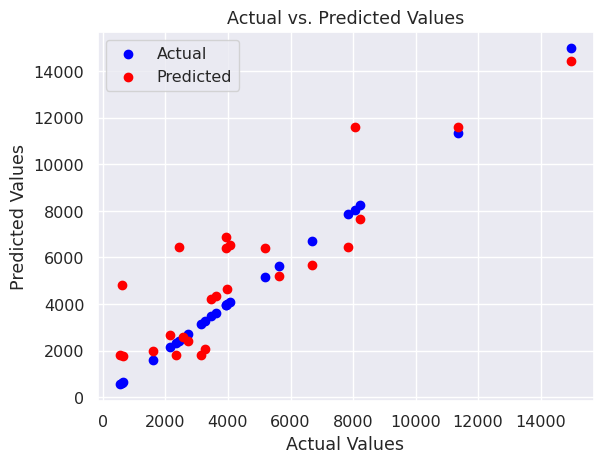

In [16]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_knn             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***LinearRegression***

In [17]:
regressor = LinearRegression()
regressor.fit(X_Train, Y_Train)
predict_LR = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LR)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LR))

Root mean square:  2691.09826866895
Mean Absolute error 2124.3101725915794


In [18]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LR)
mse = mean_squared_error(Y_Test, predict_LR)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LR)
mape = mean_absolute_percentage_error(Y_Test, predict_LR)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 2124.31
Mean Squared Error (MSE): 7242009.89
Root Mean Squared Error (RMSE): 2691.10
R-squared (R²): 0.36
mape: 61.83


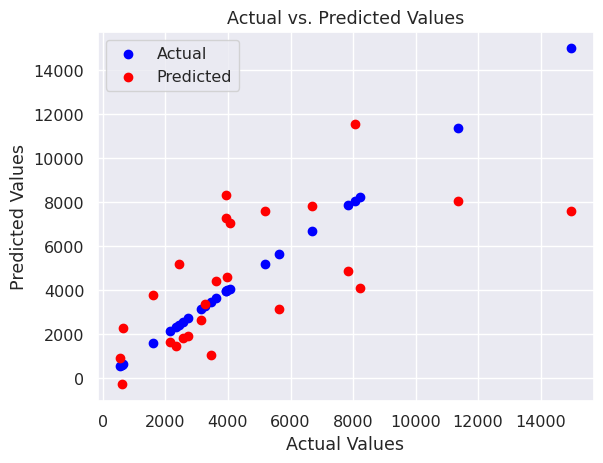

In [19]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LR             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***RandomForestRegressor***

In [20]:
regressor = RandomForestRegressor(n_estimators=100,max_features=5)
regressor.fit(X_Train, Y_Train)
predict_RF = regressor.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_RF)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_RF))

Root mean square:  3538.2066241671073
Mean Absolute error 2591.7811999999994


In [21]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [22]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_RF)
mse = mean_squared_error(Y_Test, predict_RF)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_RF)
mape = mean_absolute_percentage_error(Y_Test, predict_RF)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 2591.78
Mean Squared Error (MSE): 12518906.12
Root Mean Squared Error (RMSE): 3538.21
R-squared (R²): -0.11
mape: 86.96


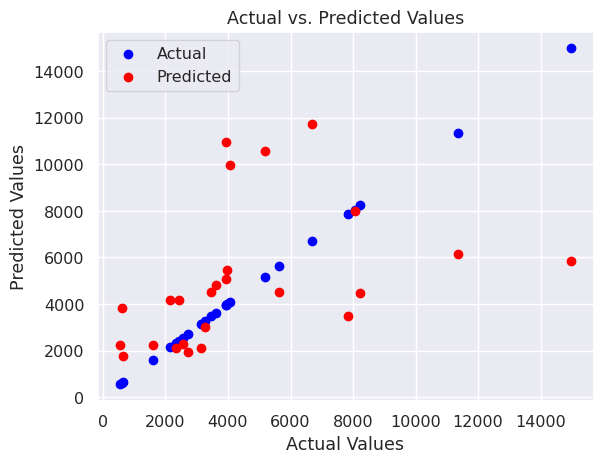

In [23]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_RF             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***SVM***

In [24]:
parameters = {'kernel':('linear', 'rbf'), 'C':[1,2,3,4,5,6,7,8,9,10, 100, 500], 'gamma':('auto', 'scale')}

svr = SVR()
LinearSVC = GridSearchCV(svr, parameters, cv=3)
LinearSVC.fit(X_Train, Y_Train)
predict_SVM = LinearSVC.predict(X_Test)
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_SVM)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_SVM))

Root mean square:  2701.493856525892
Mean Absolute error 2125.4435217369296


In [25]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [26]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_SVM)
mse = mean_squared_error(Y_Test, predict_SVM)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_SVM)
mape = mean_absolute_percentage_error(Y_Test, predict_SVM)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 2125.44
Mean Squared Error (MSE): 7298069.06
Root Mean Squared Error (RMSE): 2701.49
R-squared (R²): 0.36
mape: 64.57


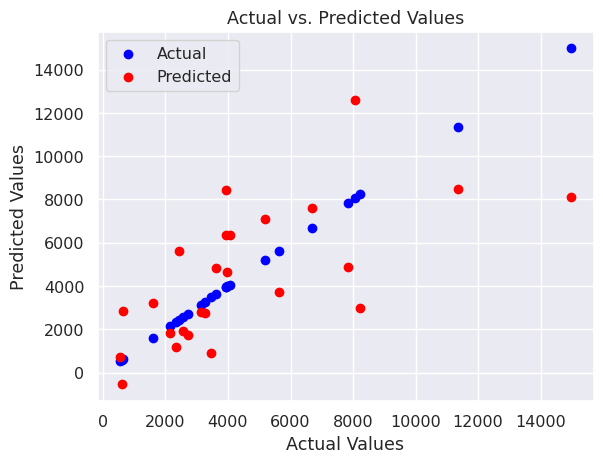

In [27]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_SVM             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()

# ***lasso***

In [28]:
from sklearn import linear_model

In [29]:
clf = linear_model.Lasso(alpha=0.1)
clf.fit(X_Train, Y_Train)
print(clf.coef_)
print(clf.intercept_)
# make a prediction
predict_LS = clf.predict(X_Test)
# summarize prediction
print("Root mean square: ", np.sqrt(mean_squared_error(Y_Test, predict_LS)))
print("Mean Absolute error", mean_absolute_error(Y_Test, predict_LS))

[317.01009622 -45.54423086 -41.07567257   2.92714792  47.42829794]
45.9133764011367
Root mean square:  2691.0829070183768
Mean Absolute error 2124.2966788713716


In [30]:
# Function to calculate Mean Absolute Percentage Error (MAPE)
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [31]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_Test, predict_LS)
mse = mean_squared_error(Y_Test, predict_LS)
rmse = np.sqrt(mse)
r_squared = r2_score(Y_Test, predict_LS)
mape = mean_absolute_percentage_error(Y_Test, predict_LS)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r_squared:.2f}")
print(f"mape: {mape:.2f}")

Mean Absolute Error (MAE): 2124.30
Mean Squared Error (MSE): 7241927.21
Root Mean Squared Error (RMSE): 2691.08
R-squared (R²): 0.36
mape: 61.83


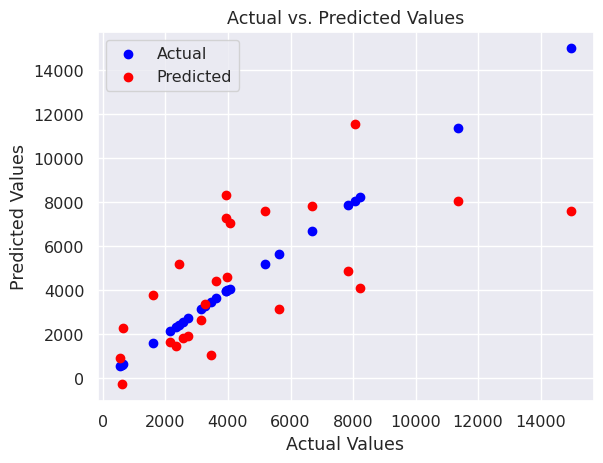

In [32]:
import matplotlib.pyplot as plt

# Sample actual and predicted values
actual_values = Y_Test                 #[0:50]
predicted_values = predict_LS             #[0:50]

# Create scatter plot for actual values
plt.scatter(actual_values, actual_values, c='blue', label='Actual')
# Create scatter plot for predicted values
plt.scatter(actual_values, predicted_values, c='red', label='Predicted')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.legend()
plt.grid(True)

plt.show()